# Sección 4: Severidad Real y Probabilidad de Ruina con Distribuciones No Exponenciales

**Tesis:** Teoría del Riesgo y Probabilidad de Ruina — Una Aproximación vía Procesos de Lévy  
**Autor:** Luis Alvarez  
**Director:** Dr. Freddy Palma Mancilla

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.optimize import brentq
from scipy.integrate import quad
from scipy.special import gamma as gamma_func
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})
np.random.seed(123)

## 1. Carga de datos

In [2]:
df = pd.read_csv('insurance_data.csv')
df = df[df['CLAIM_STATUS'] == 'A'].copy()
df['REPORT_DT'] = pd.to_datetime(df['REPORT_DT'])
df['full_incident_timestamp'] = (
    df['REPORT_DT'] + pd.to_timedelta(df['INCIDENT_HOUR_OF_THE_DAY'], unit='h')
)
df = df.sort_values('full_incident_timestamp').reset_index(drop=True)

ca = df['CLAIM_AMOUNT'].values.astype(float)
n = len(ca)
mu_Y = ca.mean()
EY2 = np.mean(ca**2)

T_days = (df['full_incident_timestamp'].max() - df['full_incident_timestamp'].min()).total_seconds() / 86400
lam = n / T_days
theta_carga = 0.40
beta = (1 + theta_carga) * lam * mu_Y
delta_exp = 1 / mu_Y

print(f'n={n}, T={T_days:.1f} días')
print(f'lambda={lam:.4f} sin/día, mu_Y=${mu_Y:,.2f}')
print(f'beta=${beta:,.2f} USD/día')

n=9497, T=407.6 días
lambda=23.2984 sin/día, mu_Y=$16,550.75
beta=$539,847.90 USD/día


## 2. Ajuste de distribuciones por MLE

In [9]:
# Exponencial
ll_exp = np.sum(np.log(delta_exp * np.exp(-delta_exp * ca)))
aic_exp = -2 * ll_exp + 2 * 1
bic_exp = -2 * ll_exp + np.log(n) * 1
ks_exp = stats.kstest(ca, 'expon', args=(0, mu_Y))

# Gamma
a_g, _, scale_g = stats.gamma.fit(ca, floc=0)
ll_gamma = np.sum(stats.gamma.logpdf(ca, a_g, loc=0, scale=scale_g))
aic_gamma = -2 * ll_gamma + 2 * 2
bic_gamma = -2 * ll_gamma + np.log(n) * 2
ks_gamma = stats.kstest(ca, 'gamma', args=(a_g, 0, scale_g))

# Weibull
c_w, _, scale_w = stats.weibull_min.fit(ca, floc=0)
ll_weib = np.sum(stats.weibull_min.logpdf(ca, c_w, loc=0, scale=scale_w))
aic_weib = -2 * ll_weib + 2 * 2
bic_weib = -2 * ll_weib + np.log(n) * 2
ks_weib = stats.kstest(ca, 'weibull_min', args=(c_w, 0, scale_w))

# Lognormal
s_ln, _, scale_ln = stats.lognorm.fit(ca, floc=0)
mu_ln = np.log(scale_ln)
sigma_ln = s_ln
ll_lognorm = np.sum(stats.lognorm.logpdf(ca, s_ln, loc=0, scale=scale_ln))
aic_lognorm = -2 * ll_lognorm + 2 * 2
bic_lognorm = -2 * ll_lognorm + np.log(n) * 2
ks_ln = stats.kstest(ca, 'lognorm', args=(s_ln, 0, scale_ln))

print('Distribución  | Parámetros MLE                    | AIC      | BIC      | KS D')
print('-' * 95)
print(f'Exponencial   | delta={delta_exp:.6e}              | {aic_exp:.0f} | {bic_exp:.0f} | {ks_exp.statistic:.4f}')
print(f'Gamma         | a={a_g:.4f}, scale={scale_g:.2f}       | {aic_gamma:.0f} | {bic_gamma:.0f} | {ks_gamma.statistic:.4f}')
print(f'Weibull       | k={c_w:.4f}, lambda={scale_w:.2f}    | {aic_weib:.0f} | {bic_weib:.0f} | {ks_weib.statistic:.4f}')
print(f'Lognormal     | mu={mu_ln:.4f}, sigma={sigma_ln:.4f}    | {aic_lognorm:.0f} | {bic_lognorm:.0f} | {ks_ln.statistic:.4f}')

print(f'\n*** Weibull k = {c_w:.4f} < 1  →  cola más pesada que exponencial')
print(f'*** Gamma  a = {a_g:.4f} < 1  →  cola más pesada que exponencial')

Distribución  | Parámetros MLE                    | AIC      | BIC      | KS D
-----------------------------------------------------------------------------------------------
Exponencial   | delta=6.042021e-05              | 203507 | 203514 | 0.1953
Gamma         | a=0.5890, scale=28101.56       | 201302 | 201317 | 0.0760
Weibull       | k=0.6989, lambda=13066.84    | 201160 | 201174 | 0.0748
Lognormal     | mu=8.6622, sigma=1.7140    | 201720 | 201734 | 0.0754

*** Weibull k = 0.6989 < 1  →  cola más pesada que exponencial
*** Gamma  a = 0.5890 < 1  →  cola más pesada que exponencial


## 3. GRÁFICA: Histograma con densidades ajustadas

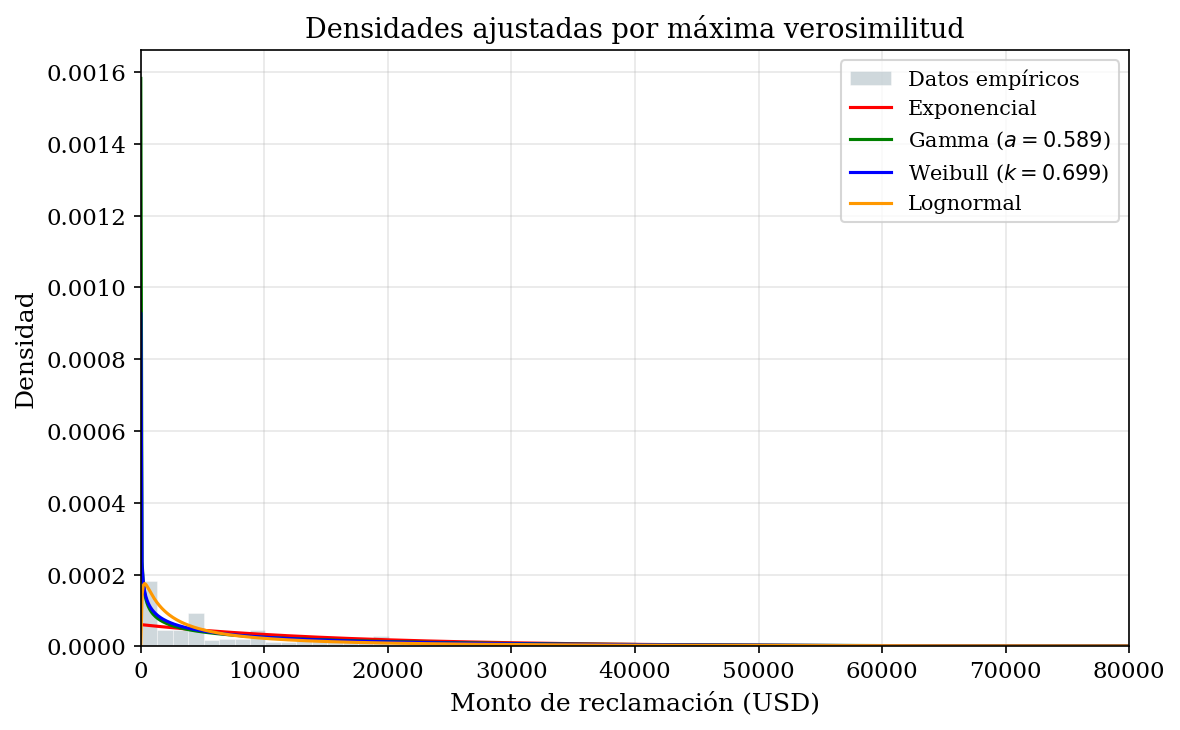

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(ca, bins=80, density=True, alpha=0.6, color='#B0BEC5',
        edgecolor='white', linewidth=0.3, label='Datos empíricos')

x_plot = np.linspace(1, ca.max(), 1000)

ax.plot(x_plot, stats.expon.pdf(x_plot, 0, mu_Y), 'r-', lw=1.5,
        label=f'Exponencial')
ax.plot(x_plot, stats.gamma.pdf(x_plot, a_g, 0, scale_g), 'g-', lw=1.5,
        label=f'Gamma ($a={a_g:.3f}$)')
ax.plot(x_plot, stats.weibull_min.pdf(x_plot, c_w, 0, scale_w), 'b-', lw=1.5,
        label=f'Weibull ($k={c_w:.3f}$)')
ax.plot(x_plot, stats.lognorm.pdf(x_plot, s_ln, 0, scale_ln), color='#FF9800',
        lw=1.5, label=f'Lognormal')

ax.set_xlabel('Monto de reclamación (USD)')
ax.set_ylabel('Densidad')
ax.set_title('Densidades ajustadas por máxima verosimilitud')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 80000)
plt.tight_layout()
plt.savefig('fig_densidades_ajuste.pdf')
plt.show()

## 4. Existencia de la MGF y coeficiente de ajuste

**Resultado clave:** Para distribuciones con cola más pesada que la exponencial  
(Weibull con k<1, Lognormal), la MGF $M_Y(R) = E[e^{RY}]$ **diverge** para todo $R > 0$.  
La desigualdad de Lundberg **no aplica**.

Solo la Exponencial y la Gamma (cuya MGF existe en forma cerrada para $R < 1/\text{scale}$) admiten coeficiente de ajuste.

In [11]:
# === Exponencial (cerrada) ===
R_exp = delta_exp - lam / beta
print(f'R_Exp    = {R_exp:.6e}')

# === Gamma: MGF = (1 - R*scale)^{-a}, existe para R < 1/scale ===
def lundberg_gamma(R, a, sc, lam_val, beta_val):
    if R <= 0 or R >= 1/sc:
        return np.inf
    mgf = (1 - R * sc)**(-a)
    return lam_val * (mgf - 1) - beta_val * R

R_gamma = brentq(lundberg_gamma, 1e-15, 1/scale_g - 1e-10,
                  args=(a_g, scale_g, lam, beta))
print(f'R_Gamma  = {R_gamma:.6e}')

# === Weibull con k < 1: MGF NO EXISTE ===
print(f'\nWeibull (k={c_w:.4f} < 1):')
print(f'  La cola decae como exp(-(x/lam)^k) con k<1, que es más lenta que exp(-cx).')
print(f'  => E[e^{{RY}}] = inf para todo R > 0.')
print(f'  => Coeficiente de Lundberg: NO EXISTE.')
print(f'  => Desigualdad de Lundberg: NO APLICA.')

# === Lognormal: MGF NO EXISTE (misma razón) ===
print(f'\nLognormal (sigma={sigma_ln:.4f}):')
print(f'  La cola decae más lento que cualquier exponencial.')
print(f'  => Coeficiente de Lundberg: NO EXISTE.')

print(f'\n=== RESUMEN ===')
print(f'Distribuciones con R finito:  Exponencial (R={R_exp:.4e}), Gamma (R={R_gamma:.4e})')
print(f'Distribuciones sin R finito:  Weibull (k<1), Lognormal')
print(f'Orden (donde aplica): R_Gamma < R_Exp')

R_Exp    = 1.726292e-05
R_Gamma  = 1.243271e-05

Weibull (k=0.6989 < 1):
  La cola decae como exp(-(x/lam)^k) con k<1, que es más lenta que exp(-cx).
  => E[e^{RY}] = inf para todo R > 0.
  => Coeficiente de Lundberg: NO EXISTE.
  => Desigualdad de Lundberg: NO APLICA.

Lognormal (sigma=1.7140):
  La cola decae más lento que cualquier exponencial.
  => Coeficiente de Lundberg: NO EXISTE.

=== RESUMEN ===
Distribuciones con R finito:  Exponencial (R=1.7263e-05), Gamma (R=1.2433e-05)
Distribuciones sin R finito:  Weibull (k<1), Lognormal
Orden (donde aplica): R_Gamma < R_Exp


## 5. Aproximación por difusión

La difusión **sí aplica** para todas las distribuciones con $E[Y^2] < \infty$.  
La Weibull con k=0.699 tiene segundo momento finito, así que la difusión funciona  
aunque la cota de Lundberg no.

In [12]:
mu_drift = beta - lam * mu_Y

# E[Y^2] para cada distribución
EY2_exp_val = EY2  # empírico = 2/delta^2 teórico
EY2_gamma_val = a_g * (a_g + 1) * scale_g**2
EY2_weib_val = scale_w**2 * gamma_func(1 + 2/c_w)

sigma2_exp = lam * EY2_exp_val
sigma2_gamma = lam * EY2_gamma_val
sigma2_weib = lam * EY2_weib_val

diff_exp = 2 * mu_drift / sigma2_exp
diff_gamma = 2 * mu_drift / sigma2_gamma
diff_weib = 2 * mu_drift / sigma2_weib

print(f'mu (ganancia neta) = ${mu_drift:,.2f} USD/día')
print(f'\n{"Distribución":>14} | {"sigma^2":>17} | {"2mu/sigma^2":>14} | {"R (Lundberg)":>14}')
print('-' * 75)
print(f'{"Exponencial":>14} | {sigma2_exp:>17,.0f} | {diff_exp:>14.6e} | {R_exp:>14.6e}')
print(f'{"Gamma":>14} | {sigma2_gamma:>17,.0f} | {diff_gamma:>14.6e} | {R_gamma:>14.6e}')
print(f'{"Weibull":>14} | {sigma2_weib:>17,.0f} | {diff_weib:>14.6e} | {"NO EXISTE":>14}')
print(f'\nNota: Para la Weibull, la difusión es la ÚNICA cota analítica disponible.')

mu (ganancia neta) = $154,242.26 USD/día

  Distribución |           sigma^2 |    2mu/sigma^2 |   R (Lundberg)
---------------------------------------------------------------------------
   Exponencial |    17,649,207,065 |   1.747866e-05 |   1.726292e-05
         Gamma |    17,218,184,502 |   1.791620e-05 |   1.243271e-05
       Weibull |    20,114,693,139 |   1.533628e-05 |      NO EXISTE

Nota: Para la Weibull, la difusión es la ÚNICA cota analítica disponible.


## 6. Simulación Monte Carlo

In [14]:
T_horizon = 100
n_sim = 1_500

u_multiples = np.array([0, 1, 2, 5, 10, 15, 20])
u_values = u_multiples * mu_Y

def simulate_CL_mc(u, beta_val, lam_val, severity_rvs, T, n_paths):
    """Simula CL path-by-path con severidad arbitraria."""
    ruined_count = 0
    for _ in range(n_paths):
        t_now, S_now = 0.0, 0.0
        is_ruined = False
        while t_now < T:
            t_now += np.random.exponential(1/lam_val)
            if t_now > T:
                break
            S_now += severity_rvs()
            if u + beta_val * t_now - S_now < 0:
                is_ruined = True
                break
        if is_ruined:
            ruined_count += 1
    return ruined_count / n_paths

# Generadores de severidad
rvs_exp   = lambda: np.random.exponential(1/delta_exp)
rvs_gamma = lambda: stats.gamma.rvs(a_g, scale=scale_g)
rvs_weib  = lambda: stats.weibull_min.rvs(c_w, scale=scale_w)

print(f'Simulación MC: {n_sim} trayectorias, T={T_horizon} días')
print(f'{"u":>12} | {"MC Exp":>9} | {"MC Gamma":>9} | {"MC Weib":>9}')
print('-' * 50)

mc_exp_list, mc_gam_list, mc_weib_list = [], [], []

for u in u_values:
    mc_e = simulate_CL_mc(u, beta, lam, rvs_exp, T_horizon, n_sim)
    mc_g = simulate_CL_mc(u, beta, lam, rvs_gamma, T_horizon, n_sim)
    mc_w = simulate_CL_mc(u, beta, lam, rvs_weib, T_horizon, n_sim)
    
    mc_exp_list.append(mc_e)
    mc_gam_list.append(mc_g)
    mc_weib_list.append(mc_w)
    
    print(f'{u:>12,.0f} | {mc_e:>9.5f} | {mc_g:>9.5f} | {mc_w:>9.5f}')

mc_exp_arr = np.array(mc_exp_list)
mc_gam_arr = np.array(mc_gam_list)
mc_weib_arr = np.array(mc_weib_list)

Simulación MC: 1500 trayectorias, T=100 días
           u |    MC Exp |  MC Gamma |   MC Weib
--------------------------------------------------
           0 |   0.69667 |   0.69467 |   0.72000
      16,551 |   0.56200 |   0.55000 |   0.58467
      33,102 |   0.39467 |   0.44467 |   0.49267
      82,754 |   0.17000 |   0.23000 |   0.26733
     165,508 |   0.04533 |   0.10667 |   0.12600
     248,261 |   0.00800 |   0.03667 |   0.05800
     331,015 |   0.00467 |   0.01200 |   0.02467


## 7. GRÁFICA: Probabilidad de ruina — escala lineal

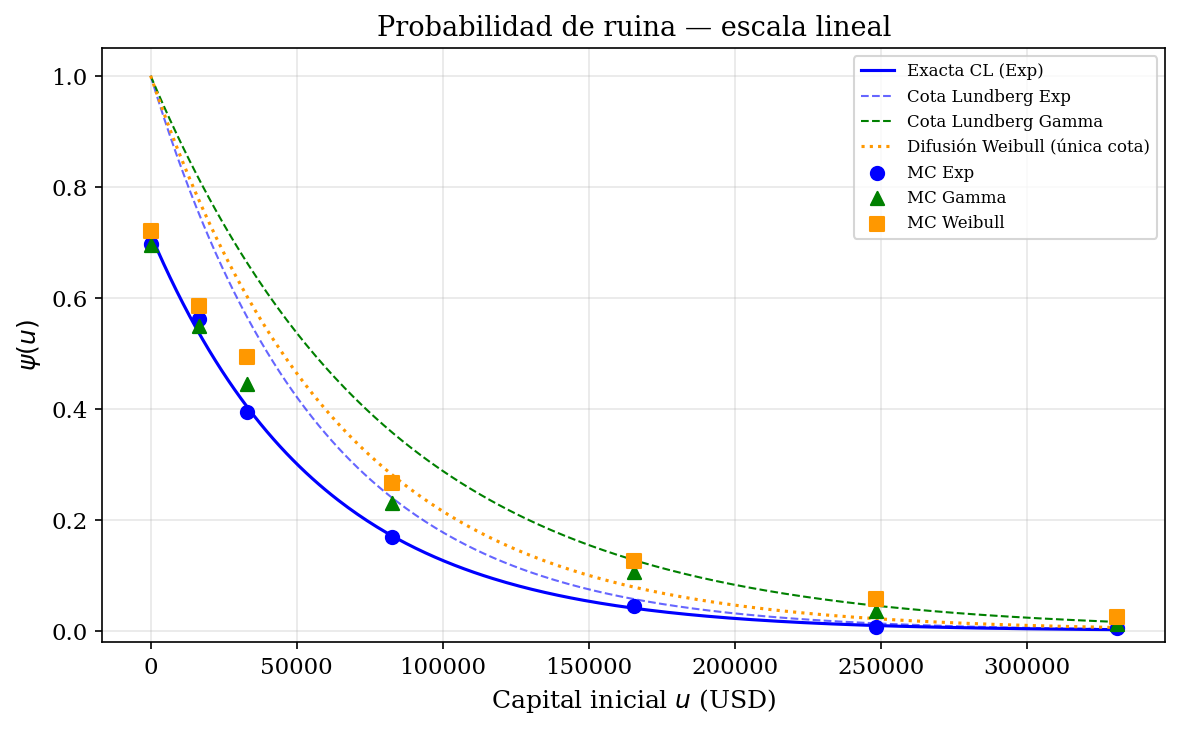

In [15]:
u_plot = np.linspace(0, 20 * mu_Y, 300)

# Fórmula exacta CL exponencial
psi_0 = lam / (delta_exp * beta)
psi_exact_exp = psi_0 * np.exp(-(delta_exp - lam/beta) * u_plot)

# Cotas de Lundberg (solo Exp y Gamma)
cota_exp_plot   = np.exp(-R_exp * u_plot)
cota_gamma_plot = np.exp(-R_gamma * u_plot)

# Difusión (las tres, incluyendo Weibull)
diff_exp_plot   = np.exp(-diff_exp * u_plot)
diff_gamma_plot = np.exp(-diff_gamma * u_plot)
diff_weib_plot  = np.exp(-diff_weib * u_plot)

fig, ax = plt.subplots(figsize=(8, 5))

# Exacta y cotas
ax.plot(u_plot, psi_exact_exp, 'b-', lw=1.5, label='Exacta CL (Exp)')
ax.plot(u_plot, cota_exp_plot, 'b--', lw=1, alpha=0.6, label='Cota Lundberg Exp')
ax.plot(u_plot, cota_gamma_plot, 'g--', lw=1, label='Cota Lundberg Gamma')

# Difusión Weibull (única cota analítica disponible)
ax.plot(u_plot, diff_weib_plot, color='#FF9800', ls=':', lw=1.5,
        label='Difusión Weibull (única cota)')

# MC points
ax.scatter(u_values, mc_exp_arr, marker='o', s=40, color='blue',
           zorder=5, label='MC Exp')
ax.scatter(u_values, mc_gam_arr, marker='^', s=40, color='green',
           zorder=5, label='MC Gamma')
ax.scatter(u_values, mc_weib_arr, marker='s', s=40, color='#FF9800',
           zorder=5, label='MC Weibull')

ax.set_xlabel('Capital inicial $u$ (USD)')
ax.set_ylabel('$\\psi(u)$')
ax.set_title('Probabilidad de ruina — escala lineal')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.02, 1.05)
plt.tight_layout()
plt.savefig('fig_psi_comparacion_lineal.pdf')
plt.show()

## 8. GRÁFICA: Probabilidad de ruina — escala logarítmica

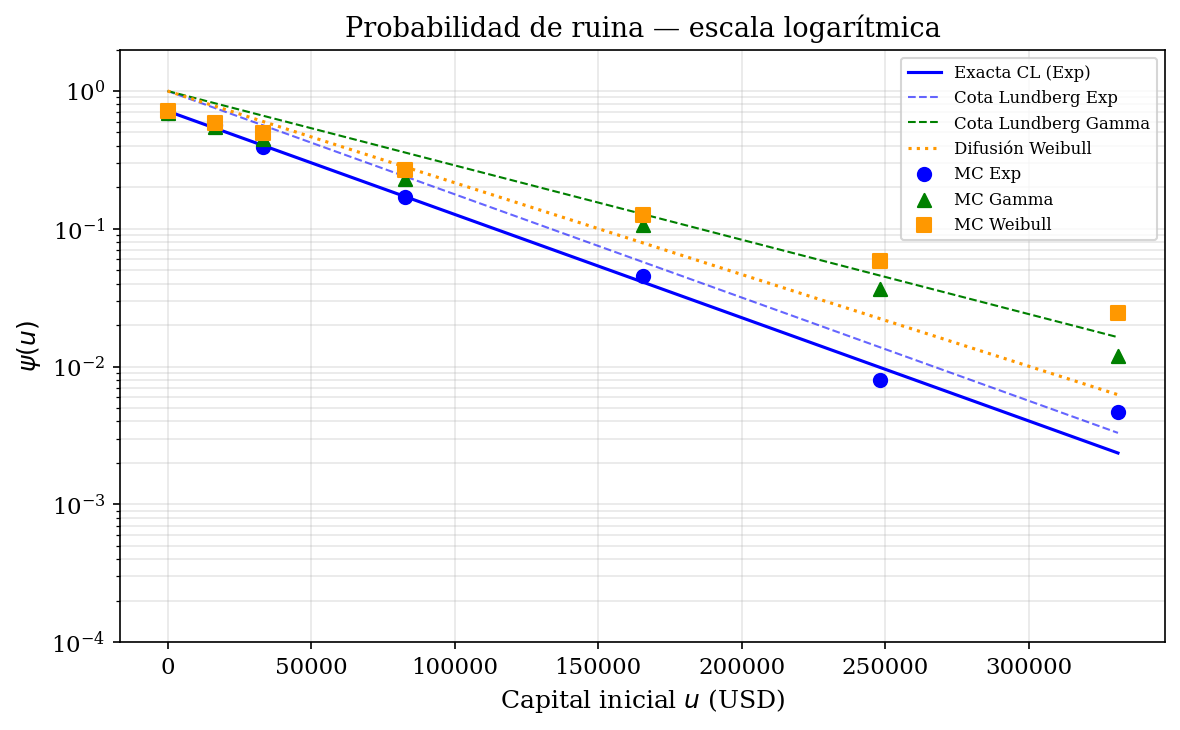

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.semilogy(u_plot, np.clip(psi_exact_exp, 1e-8, 1), 'b-', lw=1.5,
            label='Exacta CL (Exp)')
ax.semilogy(u_plot, np.clip(cota_exp_plot, 1e-8, 1), 'b--', lw=1, alpha=0.6,
            label='Cota Lundberg Exp')
ax.semilogy(u_plot, np.clip(cota_gamma_plot, 1e-8, 1), 'g--', lw=1,
            label='Cota Lundberg Gamma')
ax.semilogy(u_plot, np.clip(diff_weib_plot, 1e-8, 1), color='#FF9800',
            ls=':', lw=1.5, label='Difusión Weibull')

# MC
mask_e = mc_exp_arr > 0
mask_g = mc_gam_arr > 0
mask_w = mc_weib_arr > 0
ax.scatter(u_values[mask_e], mc_exp_arr[mask_e], marker='o', s=40,
           color='blue', zorder=5, label='MC Exp')
ax.scatter(u_values[mask_g], mc_gam_arr[mask_g], marker='^', s=40,
           color='green', zorder=5, label='MC Gamma')
ax.scatter(u_values[mask_w], mc_weib_arr[mask_w], marker='s', s=40,
           color='#FF9800', zorder=5, label='MC Weibull')

ax.set_xlabel('Capital inicial $u$ (USD)')
ax.set_ylabel('$\\psi(u)$')
ax.set_title('Probabilidad de ruina — escala logarítmica')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3, which='both')
ax.set_ylim(1e-4, 2)
plt.tight_layout()
plt.savefig('fig_psi_comparacion_log.pdf')
plt.show()

## 9. GRÁFICA: Q-Q plot Weibull

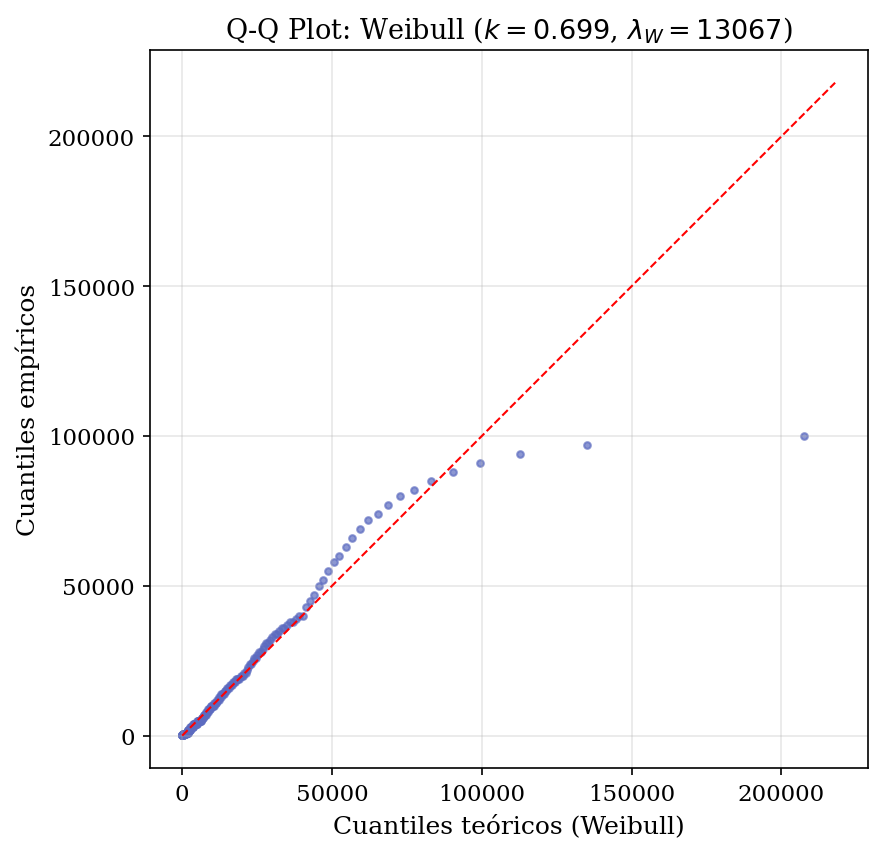

In [17]:
fig, ax = plt.subplots(figsize=(6, 6))
probs = np.linspace(0.001, 0.999, 200)
theoretical_q = stats.weibull_min.ppf(probs, c_w, 0, scale_w)
empirical_q = np.quantile(ca, probs)

ax.scatter(theoretical_q, empirical_q, s=10, alpha=0.7, color='#5C6BC0')
lim = max(theoretical_q.max(), empirical_q.max()) * 1.05
ax.plot([0, lim], [0, lim], 'r--', lw=1)
ax.set_xlabel('Cuantiles teóricos (Weibull)')
ax.set_ylabel('Cuantiles empíricos')
ax.set_title(f'Q-Q Plot: Weibull ($k={c_w:.3f}$, $\\lambda_W={scale_w:.0f}$)')
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('fig_qq_weibull.pdf')
plt.show()